# Graph-Based Museum Recommendation Engine

In this notebook, I implement a **graph-based recommendation system** using knowledge graph embeddings and link prediction. This approach models museums, artists, figures, and themes as nodes in a graph, with edges representing relationships.

## Why Graphs?

Traditional embedding approaches treat entities in isolation. A graph approach captures:
- **Transitive relationships**: Museum A → Monet → Impressionism → Museum B
- **Multi-hop connections**: Museums linked through shared artistic movements
- **Structural patterns**: Hubs (popular artists) and communities (regional clusters)

---

## 1. Building the Knowledge Graph

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')

# Load the dataset
df = pd.read_csv('../musees-de-france-base-museofile.csv', sep=';')
print(f"Dataset loaded: {len(df)} museums")

# Helper function to parse names
def parse_names(text):
    if pd.isna(text):
        return []
    names = []
    for name in text.replace(';', ',').replace('/', ',').split(','):
        name = name.strip()
        if len(name) > 3 and len(name) < 60:
            names.append(name)
    return names

def parse_themes(text):
    if pd.isna(text):
        return []
    themes = []
    for theme in text.split(';'):
        # Extract main category
        main = theme.split(':')[0].strip()
        if len(main) > 2:
            themes.append(main)
    return themes

Dataset loaded: 1227 museums


### 1.1 Creating the Graph Structure

I create a heterogeneous graph with:
- **Museum nodes**: Each museum is a node
- **Artist nodes**: Artists mentioned in museums
- **Figure nodes**: Historical figures (Personnage phare)
- **Theme nodes**: Thematic categories
- **Region nodes**: Geographic regions

In [2]:
# Create the knowledge graph
G = nx.Graph()

# Track node types for visualization
node_types = {}
museum_ids = []

# Add museum nodes
for _, row in df.iterrows():
    museum_id = row['Identifiant']
    museum_name = row.get('Nom officiel', museum_id)
    
    if pd.isna(museum_name):
        continue
        
    G.add_node(museum_id, type='museum', name=museum_name[:50])
    node_types[museum_id] = 'museum'
    museum_ids.append(museum_id)
    
    # Add artist connections
    artists = parse_names(row.get('Artiste', ''))
    for artist in artists:
        artist_node = f"artist:{artist}"
        if artist_node not in G:
            G.add_node(artist_node, type='artist', name=artist)
            node_types[artist_node] = 'artist'
        G.add_edge(museum_id, artist_node, relation='exhibits')
    
    # Add figure connections
    figures = parse_names(row.get('Personnage phare', ''))
    for figure in figures:
        figure_node = f"figure:{figure}"
        if figure_node not in G:
            G.add_node(figure_node, type='figure', name=figure)
            node_types[figure_node] = 'figure'
        G.add_edge(museum_id, figure_node, relation='features')
    
    # Add theme connections
    themes = parse_themes(row.get('Thèmes', ''))
    for theme in themes:
        theme_node = f"theme:{theme}"
        if theme_node not in G:
            G.add_node(theme_node, type='theme', name=theme)
            node_types[theme_node] = 'theme'
        G.add_edge(museum_id, theme_node, relation='has_theme')
    
    # Add region connection
    region = row.get('Région')
    if pd.notna(region):
        region_node = f"region:{region}"
        if region_node not in G:
            G.add_node(region_node, type='region', name=region)
            node_types[region_node] = 'region'
        G.add_edge(museum_id, region_node, relation='located_in')

print(f"Graph created:")
print(f"  Nodes: {G.number_of_nodes()}")
print(f"  Edges: {G.number_of_edges()}")
print(f"  Museums: {len(museum_ids)}")

# Count by type
type_counts = defaultdict(int)
for node, ntype in node_types.items():
    type_counts[ntype] += 1
print(f"\nNode types:")
for ntype, count in sorted(type_counts.items()):
    print(f"  {ntype}: {count}")

Graph created:
  Nodes: 7873
  Edges: 13929
  Museums: 1226

Node types:
  artist: 4011
  figure: 1930
  museum: 1226
  region: 16
  theme: 690


### 1.2 Graph Visualization (Sample)

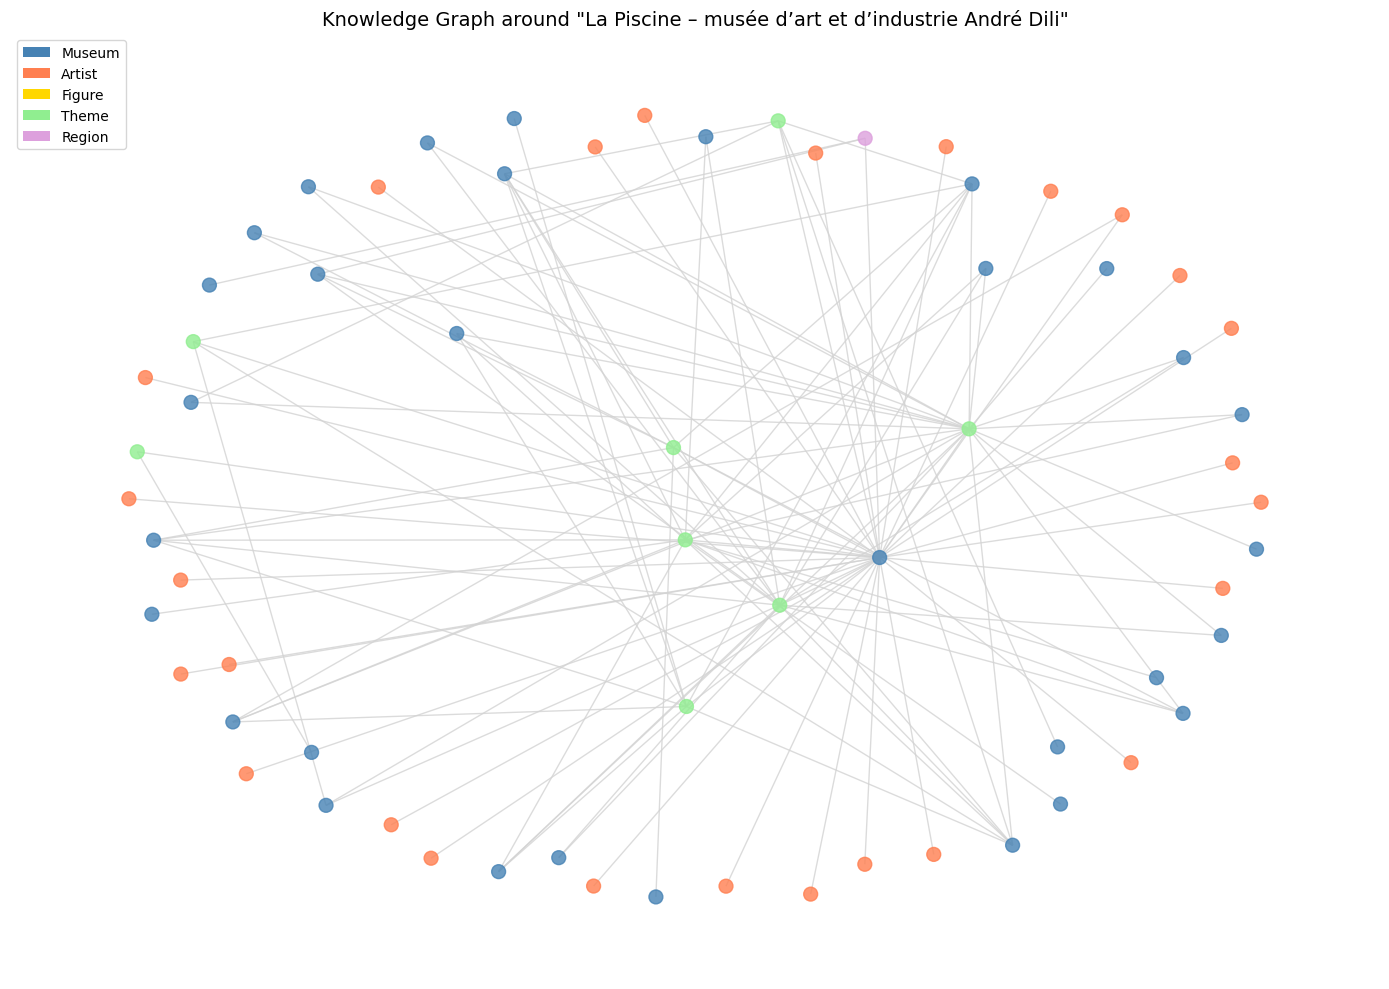

Subgraph: 66 nodes, 113 edges


In [3]:
# Visualize a subgraph around a sample museum
sample_museum = museum_ids[100]  # Pick a museum with connections

# Get 2-hop neighborhood
neighbors_1hop = set(G.neighbors(sample_museum))
neighbors_2hop = set()
for n in neighbors_1hop:
    neighbors_2hop.update(G.neighbors(n))

# Limit size for visualization
subgraph_nodes = {sample_museum} | neighbors_1hop | set(list(neighbors_2hop)[:30])
subgraph = G.subgraph(subgraph_nodes)

# Create layout
pos = nx.spring_layout(subgraph, k=2, iterations=50, seed=42)

# Color by type
color_map = {'museum': 'steelblue', 'artist': 'coral', 'figure': 'gold', 'theme': 'lightgreen', 'region': 'plum'}
node_colors = [color_map.get(node_types.get(n, 'museum'), 'gray') for n in subgraph.nodes()]

fig, ax = plt.subplots(figsize=(14, 10))
nx.draw(subgraph, pos, ax=ax,
        node_color=node_colors,
        node_size=100,
        font_size=6,
        with_labels=False,
        edge_color='lightgray',
        alpha=0.8)

# Add legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, label=t.capitalize()) for t, c in color_map.items()]
ax.legend(handles=legend_elements, loc='upper left', fontsize=10)

ax.set_title(f'Knowledge Graph around "{G.nodes[sample_museum]["name"]}"', fontsize=14)
plt.tight_layout()
plt.savefig('../outputs/graph_sample.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Subgraph: {subgraph.number_of_nodes()} nodes, {subgraph.number_of_edges()} edges")

---

## 2. Node Embeddings with Node2Vec

Node2Vec learns embeddings by performing biased random walks on the graph. The key parameters are:
- **p**: Return parameter (likelihood of returning to previous node)
- **q**: In-out parameter (controls exploration vs exploitation)

In [4]:
# Install node2vec if needed
# %pip install node2vec

from node2vec import Node2Vec

# Create Node2Vec model
print("Training Node2Vec embeddings...")
node2vec = Node2Vec(
    G, 
    dimensions=128,      # Embedding dimension
    walk_length=30,      # Length of random walks
    num_walks=100,       # Number of walks per node
    p=1,                 # Return parameter
    q=0.5,               # In-out parameter (< 1 = BFS-like, > 1 = DFS-like)
    workers=4,
    seed=42
)

# Train the model
model = node2vec.fit(window=10, min_count=1, batch_words=4)

print(f"Node2Vec model trained!")
print(f"Vocabulary size: {len(model.wv)}")
print(f"Embedding dimension: {model.wv.vector_size}")

Training Node2Vec embeddings...


Computing transition probabilities:   0%|          | 0/7873 [00:00<?, ?it/s]

Generating walks (CPU: 4): 100%|██████████| 25/25 [00:38<00:00,  1.55s/it]
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.ou

Node2Vec model trained!
Vocabulary size: 7873
Embedding dimension: 128


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


In [5]:
# Extract museum embeddings
museum_embeddings = {}
for museum_id in museum_ids:
    if museum_id in model.wv:
        museum_embeddings[museum_id] = model.wv[museum_id]

print(f"Museums with embeddings: {len(museum_embeddings)}/{len(museum_ids)}")

Museums with embeddings: 1226/1226


### 2.1 Visualizing Graph Embeddings with UMAP

Running UMAP on graph embeddings...


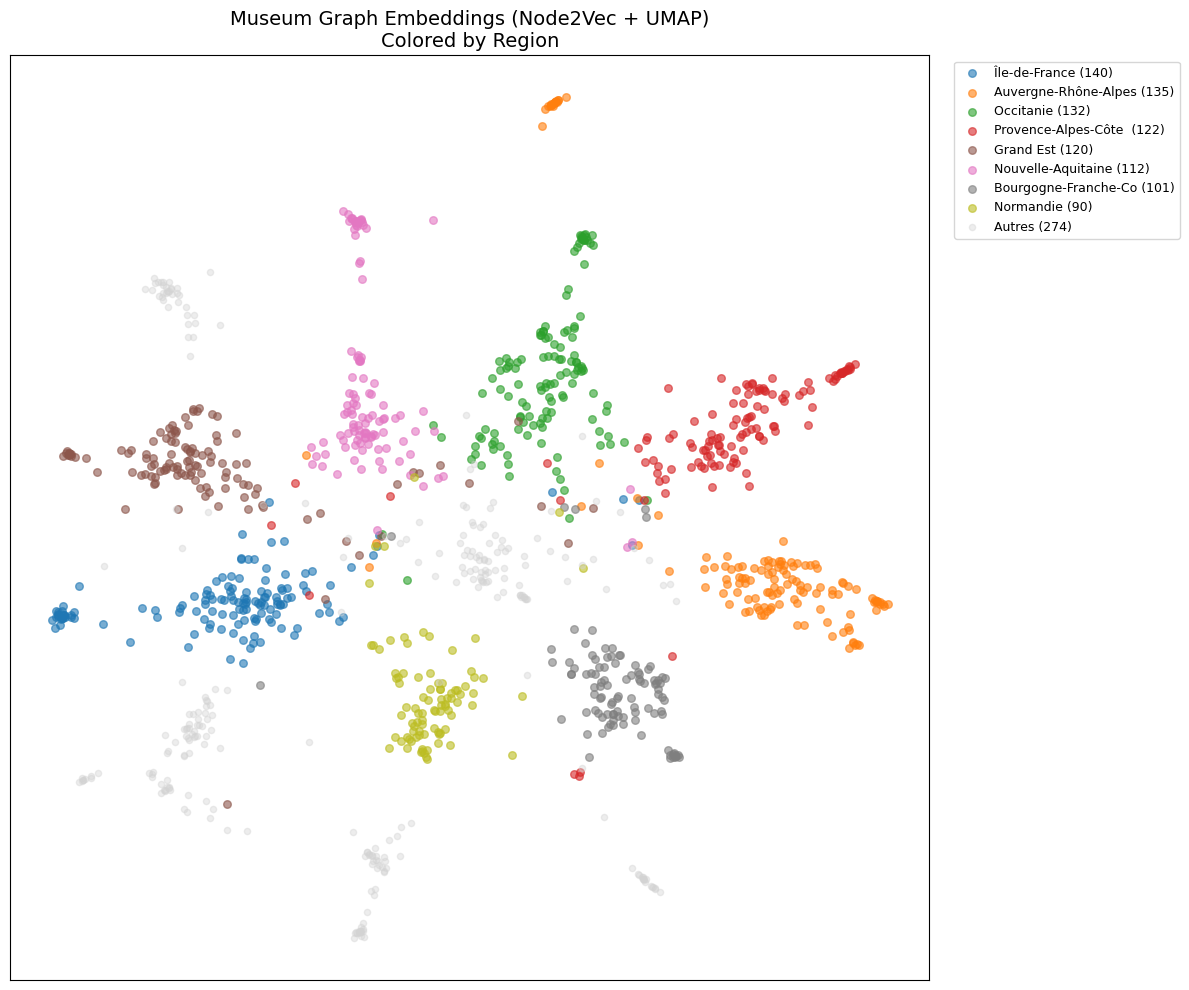

In [6]:
import umap

# Get embeddings for museums only
museum_ids_with_emb = [m for m in museum_ids if m in museum_embeddings]
X_graph = np.array([museum_embeddings[m] for m in museum_ids_with_emb])

# Apply UMAP
print("Running UMAP on graph embeddings...")
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
graph_2d = reducer.fit_transform(X_graph)

# Get regions for coloring
museum_regions = []
for m in museum_ids_with_emb:
    row = df[df['Identifiant'] == m]
    if len(row) > 0:
        region = row.iloc[0].get('Région', 'Unknown')
        museum_regions.append(region if pd.notna(region) else 'Unknown')
    else:
        museum_regions.append('Unknown')

# Get top regions
from collections import Counter
region_counts = Counter(museum_regions)
top_regions = [r for r, _ in region_counts.most_common(8)]

fig, ax = plt.subplots(figsize=(12, 10))
colors = plt.cm.tab10(np.linspace(0, 1, len(top_regions) + 1))

for i, region in enumerate(top_regions):
    mask = [r == region for r in museum_regions]
    ax.scatter(graph_2d[mask, 0], graph_2d[mask, 1],
               c=[colors[i]], label=f"{region[:20]} ({sum(mask)})",
               alpha=0.6, s=30)

# Other regions
mask = [r not in top_regions for r in museum_regions]
ax.scatter(graph_2d[mask, 0], graph_2d[mask, 1],
           c='lightgray', label=f"Autres ({sum(mask)})", alpha=0.4, s=20)

ax.set_title('Museum Graph Embeddings (Node2Vec + UMAP)\nColored by Region', fontsize=14)
ax.set_xticks([])
ax.set_yticks([])
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.savefig('../outputs/graph_embeddings_umap.png', dpi=150, bbox_inches='tight')
plt.show()

---

## 3. Graph-Based Recommendations

Using the graph embeddings, I compute similarity between museums and generate recommendations.

In [7]:
from sklearn.metrics.pairwise import cosine_similarity

# Compute similarity matrix for museums
X_museums = np.array([museum_embeddings[m] for m in museum_ids_with_emb])
sim_graph = cosine_similarity(X_museums)

# Create index mapping
museum_to_idx = {m: i for i, m in enumerate(museum_ids_with_emb)}
idx_to_museum = {i: m for i, m in enumerate(museum_ids_with_emb)}

def get_graph_recommendations(museum_id, top_k=5):
    """Get recommendations based on graph embeddings."""
    if museum_id not in museum_to_idx:
        return []
    
    idx = museum_to_idx[museum_id]
    scores = sim_graph[idx]
    
    # Get top-k (excluding self)
    top_indices = np.argsort(scores)[::-1][1:top_k+1]
    
    recommendations = []
    for i in top_indices:
        rec_id = idx_to_museum[i]
        rec_row = df[df['Identifiant'] == rec_id].iloc[0]
        recommendations.append({
            'id': rec_id,
            'name': rec_row.get('Nom officiel', rec_id),
            'region': rec_row.get('Région', 'Unknown'),
            'score': scores[i]
        })
    
    return recommendations

# Test recommendations
sample_id = museum_ids_with_emb[100]
sample_row = df[df['Identifiant'] == sample_id].iloc[0]

print(f"GRAPH-BASED RECOMMENDATIONS")
print(f"="*70)
print(f"Target: {sample_row.get('Nom officiel', sample_id)}")
print(f"Region: {sample_row.get('Région', 'Unknown')}")
print(f"Themes: {sample_row.get('Thèmes', '')[:80]}...")
print(f"\nTop 5 recommendations:")
print("-"*70)

for i, rec in enumerate(get_graph_recommendations(sample_id, 5), 1):
    print(f"{i}. {rec['name'][:50]}")
    print(f"   Region: {rec['region']} | Score: {rec['score']:.4f}")

GRAPH-BASED RECOMMENDATIONS
Target: La Piscine – musée d’art et d’industrie André Diligent de Roubaix
Region: Hauts-de-France
Themes: Architecture et urbanisme;Arts décoratifs : Céramique, Mobilier, Textiles, Verre...

Top 5 recommendations:
----------------------------------------------------------------------
1. musée du Docteur Faure
   Region: Auvergne-Rhône-Alpes | Score: 0.4591
2. musée Bonnard
   Region: Provence-Alpes-Côte d'Azur | Score: 0.4492
3. musée Municipal
   Region: Normandie | Score: 0.4211
4. musée Marcel-Sahut
   Region: Auvergne-Rhône-Alpes | Score: 0.4131
5. musée Baron Martin
   Region: Bourgogne-Franche-Comté | Score: 0.4068


### 3.1 Link Prediction for New Connections

Link prediction can suggest missing relationships in the graph. I use the learned embeddings to predict likely edges.

In [8]:
def predict_links(museum_id, entity_type='artist', top_k=5):
    """Predict likely connections for a museum."""
    if museum_id not in model.wv:
        return []
    
    museum_vec = model.wv[museum_id]
    
    # Get all entities of the specified type
    entity_nodes = [n for n in G.nodes() if node_types.get(n) == entity_type]
    
    # Compute similarities
    predictions = []
    for entity in entity_nodes:
        if entity in model.wv:
            # Skip if already connected
            if G.has_edge(museum_id, entity):
                continue
            
            entity_vec = model.wv[entity]
            sim = np.dot(museum_vec, entity_vec) / (np.linalg.norm(museum_vec) * np.linalg.norm(entity_vec))
            predictions.append((entity, sim))
    
    # Sort by similarity
    predictions.sort(key=lambda x: x[1], reverse=True)
    return predictions[:top_k]

# Example: predict missing artists for a museum
print(f"\nLINK PREDICTION: Suggested artists for '{sample_row.get('Nom officiel', sample_id)[:40]}'")
print("-"*70)

predicted_artists = predict_links(sample_id, 'artist', 10)
for entity, score in predicted_artists:
    artist_name = G.nodes[entity]['name']
    print(f"  {artist_name[:40]}: {score:.4f}")


LINK PREDICTION: Suggested artists for 'La Piscine – musée d’art et d’industrie '
----------------------------------------------------------------------
  Lalique.: 0.4528
  Desbois: 0.4443
  Ravier: 0.4443
  Henner: 0.4397
  Judy Dater: 0.4336
  Lebasque: 0.4297
  Hayez: 0.4245
  Marcel Renard: 0.4237
  dont 14 gravures avant la lettre: 0.4234
  Jongkind: 0.4229


---

## 4. Saving Graph Embeddings for Comparison

I save the graph embeddings to compare with the content-based approach.

In [9]:
# Create DataFrame with graph embeddings
graph_df = pd.DataFrame({
    'Identifiant': museum_ids_with_emb,
    'embedding_graph': [museum_embeddings[m] for m in museum_ids_with_emb]
})

# Add metadata
for col in ['Nom officiel', 'Région', 'Thèmes', 'Artiste', 'Personnage phare']:
    graph_df[col] = graph_df['Identifiant'].apply(
        lambda x: df[df['Identifiant'] == x].iloc[0].get(col) if len(df[df['Identifiant'] == x]) > 0 else None
    )

# Save
graph_df.to_pickle('../outputs/df_graph.pkl')
print(f"Graph embeddings saved to '../outputs/df_graph.pkl'")
print(f"  Museums: {len(graph_df)}")
print(f"  Embedding dimension: {len(graph_df['embedding_graph'].iloc[0])}")

# Also save the similarity matrix
np.save('../outputs/sim_graph.npy', sim_graph)
print(f"Similarity matrix saved to '../outputs/sim_graph.npy'")

# Save museum ID mapping
import pickle
with open('../outputs/museum_mapping.pkl', 'wb') as f:
    pickle.dump({'museum_to_idx': museum_to_idx, 'idx_to_museum': idx_to_museum}, f)
print(f"Museum ID mapping saved to '../outputs/museum_mapping.pkl'")

Graph embeddings saved to '../outputs/df_graph.pkl'
  Museums: 1226
  Embedding dimension: 128
Similarity matrix saved to '../outputs/sim_graph.npy'
Museum ID mapping saved to '../outputs/museum_mapping.pkl'


---

## 5. Graph Analysis

### 5.1 Centrality Analysis

Which entities are most central in the museum network?

In [10]:
# Compute centrality measures
print("Computing centrality measures...")

# Degree centrality
degree_cent = nx.degree_centrality(G)

# Get top entities by type
def top_by_centrality(node_type, top_k=10):
    entities = [(n, degree_cent[n]) for n in G.nodes() if node_types.get(n) == node_type]
    entities.sort(key=lambda x: x[1], reverse=True)
    return entities[:top_k]

print("\nTop 10 Most Connected Artists:")
for node, cent in top_by_centrality('artist', 10):
    name = G.nodes[node]['name']
    degree = G.degree(node)
    print(f"  {name[:40]}: {degree} museums")

print("\nTop 10 Most Connected Themes:")
for node, cent in top_by_centrality('theme', 10):
    name = G.nodes[node]['name']
    degree = G.degree(node)
    print(f"  {name[:40]}: {degree} museums")

print("\nTop 10 Most Connected Figures:")
for node, cent in top_by_centrality('figure', 10):
    name = G.nodes[node]['name']
    degree = G.degree(node)
    print(f"  {name[:40]}: {degree} museums")

Computing centrality measures...

Top 10 Most Connected Artists:
  Delacroix: 27 museums
  Rubens: 26 museums
  Picasso: 26 museums
  Corot: 25 museums
  Courbet: 23 museums
  Rodin: 20 museums
  Boucher: 20 museums
  Monet: 17 museums
  Dufy: 17 museums
  Boudin: 17 museums

Top 10 Most Connected Themes:
  Beaux-Arts: 551 museums
  Arts décoratifs: 486 museums
  Histoire: 469 museums
  Ethnologie: 430 museums
  Archéologie nationale: 371 museums
  Collections militaires: 227 museums
  Sciences de la nature: 221 museums
  Sciences et techniques: 203 museums
  Civilisations extra-européennes: 155 museums
  Art moderne et contemporain: 138 museums

Top 10 Most Connected Figures:
  Napoléon Ier: 9 museums
  Louis XVI: 4 museums
  Napoléon III: 4 museums
  Louis XIV: 4 museums
  Madame de Sévigné: 4 museums
  Jeanne d'Arc: 4 museums
  Napoléon Bonaparte: 3 museums
  Bonnard: 3 museums
  Delacroix: 3 museums
  Pierre Loti: 3 museums


### 5.2 Community Detection

Identifying clusters of related museums.

In [11]:
from networkx.algorithms import community

# Extract museum-only subgraph with connections through shared entities
museum_graph = nx.Graph()
for m1 in museum_ids:
    for m2 in museum_ids:
        if m1 < m2:  # Avoid duplicates
            # Count shared neighbors (artists, themes, etc.)
            shared = len(set(G.neighbors(m1)) & set(G.neighbors(m2)))
            if shared >= 2:  # Minimum 2 shared entities
                museum_graph.add_edge(m1, m2, weight=shared)

print(f"Museum-to-museum graph: {museum_graph.number_of_nodes()} nodes, {museum_graph.number_of_edges()} edges")

# Detect communities
if museum_graph.number_of_edges() > 0:
    communities = list(community.louvain_communities(museum_graph, seed=42))
    print(f"\nCommunities detected: {len(communities)}")
    
    # Analyze top communities
    communities_sorted = sorted(communities, key=len, reverse=True)[:5]
    
    for i, comm in enumerate(communities_sorted):
        print(f"\nCommunity {i+1} ({len(comm)} museums):")
        # Get common themes in this community
        theme_counts = defaultdict(int)
        for m in list(comm)[:20]:
            row = df[df['Identifiant'] == m]
            if len(row) > 0:
                themes = parse_themes(row.iloc[0].get('Thèmes', ''))
                for t in themes:
                    theme_counts[t] += 1
        
        top_themes = sorted(theme_counts.items(), key=lambda x: x[1], reverse=True)[:3]
        print(f"  Top themes: {', '.join([t for t, _ in top_themes])}")
        
        # Sample museums
        sample_museums = list(comm)[:3]
        for m in sample_museums:
            row = df[df['Identifiant'] == m]
            if len(row) > 0:
                print(f"  - {row.iloc[0].get('Nom officiel', m)[:50]}")

Museum-to-museum graph: 1057 nodes, 193075 edges

Communities detected: 6

Community 1 (342 museums):
  Top themes: Beaux-Arts, Arts décoratifs, Archéologie nationale
  - musée de l'Image Populaire
  - musée précolombien Edgar Clerc
  - musée Nicolas Poussin

Community 2 (320 museums):
  Top themes: Ethnologie, Histoire, Sciences et techniques
  - musée de l’imprimerie et de la communication graph
  - musée de la pêche
  - musée de la Chemiserie et de L'Elégance Masculine

Community 3 (269 museums):
  Top themes: Archéologie nationale, Sciences de la nature, Histoire
  - musée municipal
  - musée Archéologique départemental du Val-d'Oise
  - muséum d'histoire naturelle

Community 4 (121 museums):
  Top themes: Histoire, Beaux-Arts, Autres collections
  - musée de la maison de Pierre Loti
  - musée Jeanne d'Aboville
  - musée du vieil Argenteuil

Community 5 (3 museums):
  Top themes: ETHNOLOGIE, Métiers et Outils, SCIENCES ET TECHNIQUES
  - musée du Textile
  - écomusée du Véron
  - mu

---

## Conclusion

### Graph-Based Approach Summary

| Component | Description |
|-----------|-------------|
| **Knowledge Graph** | Museums, artists, figures, themes, regions as nodes |
| **Node2Vec** | 128-dim embeddings from biased random walks |
| **Link Prediction** | Suggest missing museum-entity connections |
| **Community Detection** | Identify thematic clusters |

### Key Insights

1. **Graph structure** captures multi-hop relationships between museums
2. **Centrality analysis** reveals influential artists and themes
3. **Communities** emerge naturally from shared entities
4. **Link prediction** can suggest missing connections

### Files Saved for Comparison

- `df_graph.pkl`: Museum embeddings from graph
- `sim_graph.npy`: Graph-based similarity matrix
- `museum_mapping.pkl`: ID to index mappings

These will be used in the comparison notebook.